## 1. NumPy: por qué una lista no basta

Antes de pandas existió NumPy, y pandas está construido encima. Su objeto central es el
**`ndarray`**: una rejilla de valores **todos del mismo tipo**. Esa restricción, que parece
una pérdida, es de donde sale todo lo demás. Como NumPy sabe de antemano que un array son
diez millones de `float64` y no una mezcla de cualquier cosa, puede guardarlos en un bloque
contiguo de memoria y recorrerlos con código compilado en C, sin preguntarse en cada
elemento de qué tipo es.

De ahí salen las dos ventajas, que son la misma vista por dos lados:

1. **Velocidad.** Multiplicar un millón de precios por 1,21 con un bucle de Python tarda
   decenas de milisegundos; con NumPy, uno o dos.
2. **Vectorización.** Escribes `precios * 1.21` y se aplica al array entero. El bucle sigue
   existiendo, pero lo ejecuta C por ti. Menos código y menos sitios donde equivocarse.

La segunda idea de la sesión es la **máscara booleana**. Cuando comparas un array con un
valor —`a != -999`— no obtienes `True` o `False`: obtienes *un array de booleanos*, uno por
elemento. Y un array de booleanos puede usarse como índice. `a[a != -999]` devuelve solo los
elementos donde la máscara vale `True`. Filtrar deja de ser un bucle con un `if` dentro y
pasa a ser una expresión.

**Cuándo se usa:** cálculo numérico sobre muchos datos homogéneos.
**Cuándo NO:** tablas con columnas de tipos distintos y nombres — para eso está pandas.
**Qué asume:** que todo el array es del mismo tipo. Si metes un texto en un array de
números, NumPy convierte el array entero a texto sin avisarte.

### Demostración guiada — vectorización y máscaras

La ejecutamos juntos. No hay que escribirla. Fíjate en dos cosas: el factor que marca el
cronómetro y, sobre todo, **qué imprime la máscara antes de usarla como índice**.

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

# Controlamos la resolución de las figuras: el notebook se entrega con las
# salidas guardadas y las imágenes pesan.
plt.rcParams['figure.dpi'] = 90

# --- 1. El mismo cálculo, de dos formas ---------------------------------
N = 1_000_000
precios_lista = [float(i) for i in range(N)]
precios_array = np.arange(N, dtype=float)

t0 = time.perf_counter()
con_iva_lista = []
for p in precios_lista:            # el bucle lo ejecuta Python, elemento a elemento
    con_iva_lista.append(p * 1.21)
t_bucle = time.perf_counter() - t0

t0 = time.perf_counter()
con_iva_array = precios_array * 1.21    # el bucle lo ejecuta C, de una vez
t_numpy = time.perf_counter() - t0

print(f"Bucle de Python  : {t_bucle * 1000:7.1f} ms")
print(f"NumPy vectorizado: {t_numpy * 1000:7.2f} ms")
print(f"Factor: x{t_bucle / t_numpy:.0f}")

# --- 2. La máscara booleana, paso a paso --------------------------------
lecturas = np.array([12.0, -1.0, 15.5, 14.2, -1.0, 13.8])

mascara = lecturas != -1.0         # esto NO es True/False: es un array de booleanos

print("\nEl array    :", lecturas)
print("La máscara  :", mascara)
print("El filtrado :", lecturas[mascara])
print("Todo junto  :", lecturas[lecturas != -1.0])

Bucle de Python  :    65.9 ms
NumPy vectorizado:    2.76 ms
Factor: x24

El array    : [12.  -1.  15.5 14.2 -1.  13.8]
La máscara  : [ True False  True  True False  True]
El filtrado : [12.  15.5 14.2 13.8]
Todo junto  : [12.  15.5 14.2 13.8]


**Qué se ve.** El factor ronda las decenas —varía según la máquina, pero el orden de
magnitud se mantiene—. Y lo importante no es solo que NumPy sea rápido: es que el código
vectorizado *también es más corto*. Cuatro líneas de bucle se convierten en una expresión.

En la segunda parte está el concepto que hay que llevarse. `lecturas != -1.0` no responde
"sí" o "no": devuelve `[True, False, True, True, False, True]`, un booleano por elemento.
Meter eso entre corchetes selecciona las posiciones marcadas como `True`. Esta misma idea
reaparece enseguida en pandas con el nombre de **filtro**, y se usa en todas las sesiones
que quedan del curso.

---
## Ejercicio 1 — Los sensores de la planta

**Contexto.** Trabajas en una planta de tratamiento de aguas. Las sondas de temperatura
vuelcan sus lecturas en un fichero, y el fabricante decidió hace veinte años que cuando una
sonda falla no escribe nada raro: escribe `-999.0`. Nadie lo ha cambiado desde entonces. Tu
equipo va a montar un informe diario de temperaturas y te toca el primer paso: pasar de la
lista en bruto a las cifras que el informe necesita, en grados Fahrenheit, porque el cliente
es americano.

**Datos de partida:** `[15.5, 17.2, 16.8, -999.0, 18.1, 14.9, 17.2, -999.0, 18.3]`

**Tu tarea.**
1. Crea un array de NumPy a partir de la lista.
2. Usando **indexación booleana**, crea `temperaturas_validas` con los valores que no sean
   `-999.0`.
3. Convierte las válidas a Fahrenheit (`F = C * 9/5 + 32`) **en una sola línea**.
4. Calcula la temperatura media, máxima y mínima en Fahrenheit.
5. Imprime cuántas lecturas has descartado. En el informe diario eso es un dato, no un
   detalle: una sonda que falla la mitad del día hay que cambiarla.

**Criterio de que lo has hecho bien:** si tu temperatura media sale por debajo del punto de
congelación, no has filtrado nada y estás promediando los códigos de error. El número de
lecturas descartadas tiene que coincidir con los `-999.0` que se ven a simple vista.

In [3]:
# TODO: completa esta celda
# `temperaturas != -999.0` ya es un array de booleanos: imprímelo antes de usarlo como índice.
# Los estadísticos son métodos del propio array (`.mean()`, `.max()`), no funciones sueltas.

import numpy as np

lecturas = np.array([15.5, 17.2, 16.8, -999.0, 18.1, 14.9, 17.2, -999.0, 18.3])

mascara = lecturas != -999.0
print("Máscara:", mascara, "\n")#hace de filtrado

validas = lecturas[mascara]

temp_farh = validas * 9/5 + 32

descartadas = lecturas.size - validas.size

print("Lecturas válidas:", validas, "\n")
print("Lecturas Descartadas:", descartadas, "\n")
print("Temperaturas en Fahrenheit:", temp_farh, "\n")
print("Máxima en Fahrenheit:", temp_farh.max())
print(f"Media en Fahrenheit: {temp_farh.mean():.2f}")
print("Minima en Fahrenheit:", temp_farh.min())

Máscara: [ True  True  True False  True  True  True False  True] 

Lecturas válidas: [15.5 17.2 16.8 18.1 14.9 17.2 18.3] 

Lecturas Descartadas: 2 

Temperaturas en Fahrenheit: [59.9  62.96 62.24 64.58 58.82 62.96 64.94] 

Máxima en Fahrenheit: 64.94
Media en Fahrenheit: 62.34
Minima en Fahrenheit: 58.82


## 2. pandas: el Excel con superpoderes

NumPy es estupendo mientras todo sea del mismo tipo. Pero los datos reales llegan en tablas
donde una columna es un número, la siguiente un texto y la de más allá una fecha, y donde
las columnas tienen **nombre**. Para eso está pandas.

Dos objetos y ya está:

- **`DataFrame`**: la tabla entera. Filas y columnas, como una hoja de cálculo, pero con un
  índice explícito y métodos para casi todo.
- **`Series`**: una sola columna. Por dentro es un array de NumPy con etiquetas pegadas, así
  que **todo lo de la sección anterior sigue valiendo**: vectorización y máscaras booleanas
  funcionan igual.

El trabajo con un fichero nuevo siempre empieza igual, y conviene convertirlo en un reflejo:
cargar, y acto seguido mirar `.head()` para ver la pinta que tiene, `.info()` para saber
cuántas filas hay, de qué tipo es cada columna y **dónde faltan valores**, y `.describe()`
para el resumen numérico. Tres comandos antes de tocar nada.

A partir de aquí trabajamos con el pasaje del Titanic: 891 personas, y para cada una si
sobrevivió, en qué clase viajaba, su edad, su sexo, cuánto pagó y con quién iba. Es pequeño,
es famoso y tiene justo los defectos que interesa aprender a detectar. **Volverá a aparecer
en la sesión 11**, allí para enseñar cómo un dataset puede filtrar la respuesta sin que te
des cuenta.

### Demostración guiada — cargar e inspeccionar

La ejecutamos juntos. Lo que hay que mirar no es la tabla: es la columna `Non-Null Count`
de `.info()`.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# 1. Cargar desde una URL pública: read_csv acepta una ruta local o una dirección web
URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(URL)

# 2. ¿Qué pinta tiene?
print("--- Primeras 5 filas ---")
print(df.head())

# 3. ¿Cuántas filas, qué tipos, cuántos nulos?
print("\n--- Información general ---")
df.info()

# 4. Resumen de las columnas numéricas
print("\n--- Resumen estadístico ---")
print(df.describe().round(2))

--- Primeras 5 filas ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

**Qué se ve.** 891 filas y 12 columnas. Y en `.info()`, el dato que importa:

| Columna | Valores presentes | Faltan |
|---|---|---|
| `Age` | 714 | **177** |
| `Cabin` | 204 | **687** |
| `Embarked` | 889 | 2 |

Tres columnas incompletas y **tres problemas distintos**. A `Embarked` le faltan 2 de 889:
es irrelevante, se rellena y a otra cosa. A `Age` le falta el **20 %**: eso ya es una
decisión con consecuencias, y la tomarás tú en el ejercicio 2. Y `Cabin` está vacía en un
77 % de las filas: una columna así normalmente no se rellena, se tira, porque lo que
quedaría sería mayoritariamente invención.

Fíjate también en `.describe()`: `Fare` va de 0 a 512 con una media de 32 y una mediana de
14,45. Media muy por encima de la mediana significa que hay unos pocos billetes carísimos
tirando del promedio hacia arriba. Un dato que la tabla da gratis y que un `head()` no
enseña.

## 3. Seleccionar, filtrar y transformar

Aquí es donde la máscara booleana de NumPy reaparece con otro nombre. Cuatro operaciones
cubren casi todo el trabajo diario:

- **Seleccionar una columna:** `df['Fare']` devuelve una `Series`. Con dobles corchetes,
  `df[['Fare', 'Age']]`, devuelve un `DataFrame` de dos columnas. La diferencia parece
  cosmética hasta que un método no existe donde lo buscas.
- **Filtrar filas:** `df[df['Age'] > 60]`. Por dentro es exactamente lo de antes —
  `df['Age'] > 60` es una `Series` de booleanos— solo que ahora selecciona filas enteras.
- **Crear columnas:** `df['NuevaColumna'] = ...`. Se calcula de forma vectorizada sobre toda
  la tabla, sin bucle.
- **Tratar los nulos:** primero se cuentan con `df.isnull().sum()` y después se decide.
  `.fillna(valor)` los rellena, `.dropna()` tira las filas. **La estrategia depende de la
  columna**, y no hay una respuesta por defecto: una edad que falta se puede aproximar por
  la mediana, pero un puerto de embarque que falta no tiene mediana y se rellena con el
  valor más frecuente.

### Demostración guiada — filtrar, crear y rellenar

Tres cosas en esta celda: un filtro, una columna nueva y un `fillna` sobre `Embarked`. La
columna `Age` **no** se toca aquí: esa decisión es tuya en el ejercicio 2.

In [5]:
# --- 1. Seleccionar: Series frente a DataFrame ---------------------------
print(type(df['Fare']))        # Series
print(type(df[['Fare']]))      # DataFrame de una columna

# --- 2. Filtrar con una máscara booleana ---------------------------------
mayores = df[df['Age'] > 60]
print(f"\nPasajeros de más de 60 años: {len(mayores)}")
print(mayores[['Name', 'Age', 'Pclass']].head(3).to_string())

# Las condiciones se combinan con & (y) y | (o), cada una entre paréntesis
mujeres_primera = df[(df['Sex'] == 'female') & (df['Pclass'] == 1)]
print(f"\nMujeres en primera clase: {len(mujeres_primera)}")

# --- 3. Crear una columna derivada, vectorizada --------------------------
# ¿Pagó este pasajero por encima de lo que pagó la mitad del barco?
df['PagoAlto'] = df['Fare'] > df['Fare'].median()
print("\n", df[['Fare', 'Pclass', 'PagoAlto']].head(5).to_string())

# --- 4. Un truco que se usará todo el curso ------------------------------
# La media de una columna de True/False es la PROPORCION de True
print(f"\nProporción de pasajeros en tercera clase: {(df['Pclass'] == 3).mean() * 100:.1f} %")

# --- 5. Nulos: contar primero, decidir después ---------------------------
print("\nNulos por columna (solo las que tienen):")
print(df.isnull().sum()[lambda s: s > 0])

# Embarked: solo 2 nulos y es texto -> el valor más frecuente (la moda)
print(f"\nPuerto más frecuente: {df['Embarked'].mode()[0]}")
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print(f"Nulos en Embarked tras rellenar: {df['Embarked'].isnull().sum()}")

<class 'pandas.Series'>
<class 'pandas.DataFrame'>

Pasajeros de más de 60 años: 22
                              Name   Age  Pclass
33           Wheadon, Mr. Edward H  66.0       2
54  Ostby, Mr. Engelhart Cornelius  65.0       1
96       Goldschmidt, Mr. George B  71.0       1

Mujeres en primera clase: 94

       Fare  Pclass  PagoAlto
0   7.2500       3     False
1  71.2833       1      True
2   7.9250       3     False
3  53.1000       1      True
4   8.0500       3     False

Proporción de pasajeros en tercera clase: 55.1 %

Nulos por columna (solo las que tienen):
Age         177
Cabin       687
Embarked      2
dtype: int64

Puerto más frecuente: S
Nulos en Embarked tras rellenar: 0


**Qué se ve.** 22 pasajeros de más de 60 años, y 94 mujeres en primera clase, sin un solo
bucle. Las condiciones se encadenan con `&` y `|` —no con `and` y `or`, que aquí no
funcionan— y **cada una necesita sus paréntesis**, porque en Python `&` tiene más prioridad
que `>`.

Los dos puntos que conviene no pasar por alto:

**El truco del punto 4.** Un `True` vale 1 y un `False` vale 0, así que la media de una
columna de booleanos es la proporción de verdaderos. Ese 55,1 % de tercera clase ha salido
de un `.mean()`. En el ejercicio 2 lo vas a usar para calcular tasas de supervivencia, y en
el bloque 3 para tasas de acierto.

**El `fillna` del punto 5.** A `Embarked` le faltaban dos valores y se ha rellenado con `S`,
que es el puerto más frecuente. Se ha hecho sin pensarlo mucho **porque son dos filas de
891**. Con `Age` habría 177 y la misma operación ya no sería inocente. Es la misma función y
una decisión completamente distinta.

## 4. `groupby`: separar, aplicar, combinar

`.groupby()` es la herramienta que convierte una tabla en una respuesta. Responde a
preguntas de la forma *"¿cómo cambia X según Y?"*, que son casi todas las preguntas que se
hacen en una empresa.

Funciona en tres pasos, y merece la pena tenerlos presentes porque explican la sintaxis:

1. **Separar** las filas en grupos según una columna (hombres y mujeres).
2. **Aplicar** una función a cada grupo por separado (la media de la edad).
3. **Combinar** los resultados en una tabla nueva, con un grupo por fila.

Escrito, son estos tres pasos en este orden: `df.groupby('Sex')['Age'].mean()`. Primero por
qué columna se separa, después sobre qué columna se calcula, y al final qué se calcula.

Dos parientes cercanos que conviene no confundir. **`.value_counts()`** cuenta cuántas filas
hay de cada valor de una columna: es un `groupby` de contar, y no necesita una segunda
columna. **`.sort_values()`** no agrupa nada, solo ordena; se usa casi siempre *después* de
un `groupby`, porque el resultado sale ordenado por el nombre del grupo y lo que suele
interesar es ordenarlo por el número.

### Demostración guiada — responder preguntas con `groupby`

La pregunta de negocio: *¿los pasajeros que embarcaron en un puerto pagaron más que los de
otro?*

In [6]:
# --- 1. Cuántos embarcaron en cada puerto (value_counts: solo cuenta) ----
print("Pasajeros por puerto:")
print(df['Embarked'].value_counts())

# --- 2. Cuánto pagó de media cada puerto (groupby: separar-aplicar-combinar)
precio_por_puerto = df.groupby('Embarked')['Fare'].mean().round(2)
print("\nPrecio medio del billete por puerto:")
print(precio_por_puerto.sort_values(ascending=False))   # ordenado por el número

# --- 3. Varias métricas de golpe con .agg() ------------------------------
print("\nResumen por puerto:")
print(df.groupby('Embarked')['Fare'].agg(['count', 'mean', 'median']).round(2))

# --- 4. Agrupar por dos columnas a la vez --------------------------------
# unstack() pasa el segundo nivel del índice a columnas: se lee mucho mejor
print("\nPrecio medio por puerto Y clase:")
print(df.groupby(['Embarked', 'Pclass'])['Fare'].mean().round(2).unstack())

Pasajeros por puerto:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

Precio medio del billete por puerto:
Embarked
C    59.95
S    27.24
Q    13.28
Name: Fare, dtype: float64

Resumen por puerto:
          count   mean  median
Embarked                      
C           168  59.95   29.70
Q            77  13.28    7.75
S           646  27.24   13.00

Precio medio por puerto Y clase:
Pclass         1      2      3
Embarked                      
C         104.72  25.36  11.21
Q          90.00  12.35  11.18
S          70.51  20.33  14.64


**Qué se ve.** La respuesta directa es que sí: Cherbourg 59,95 de media, Southampton 27,24 y
Queenstown 13,28. Cherbourg sale cuatro veces y media más caro que Queenstown.

**Y es una respuesta engañosa.** Mira la tabla del punto 4. Dentro de la primera clase, un
billete de Queenstown costaba 90,00 y uno de Southampton 70,51: por clase, Queenstown no es
barato en absoluto. Lo que cambia entre puertos no es el precio, es **la mezcla de clases**
de quien subió en cada uno. El promedio global estaba escondiendo esa diferencia detrás de
una sola cifra.

Este es el motivo real por el que existe `groupby`, y conviene quedarse con él: **una media
sobre un grupo mezclado responde a una pregunta que no es la que hiciste**. Un solo número
para toda la tabla casi nunca es la respuesta; la respuesta suele ser un número por grupo.

---
## Preguntas de recap – NumPy, pandas y groupby

1. ¿Qué ventaja tienen los **DataFrames de pandas** frente a listas o diccionarios para
   trabajar con datos?
2. ¿Qué diferencia hay entre `df.head()` y `df.info()`? ¿Cuál usarías para descubrir que
   faltan valores?
3. Si tengo un DataFrame con una columna de texto llamada `"nombre"`, ¿cómo selecciono solo
   esa columna? ¿Y cómo me quedo con las filas donde esa columna vale `"Ana"`?
4. ¿Cómo podemos manejar los valores nulos en pandas, y de qué depende elegir una forma u
   otra?
5. ¿Cuáles son los tres pasos que hace `.groupby()` por dentro?

## 5. Visualización con seaborn

Una tabla de números es una respuesta; un gráfico es una respuesta que se entiende de un
vistazo. Seaborn está hecho para eso: gráficos estadísticos decentes con una línea de
código, y entiende los DataFrames de pandas directamente.

Lo que hay que aprender aquí no es la sintaxis, que es casi siempre la misma
—`sns.loquesea(data=df, x=..., y=...)`—. Es **qué gráfico corresponde a qué pregunta**:

| La pregunta | El gráfico |
|---|---|
| ¿Cómo se reparten los valores de una variable numérica? | **Histograma** (`histplot`) |
| ¿Cuántas filas hay de cada categoría? | **Conteo** (`countplot`) |
| ¿Cómo cambia un número entre categorías? | **Barras** (`barplot`) |
| ¿Y cómo de dispersos están dentro de cada categoría? | **Cajas** (`boxplot`) |
| ¿Se relacionan dos variables numéricas entre sí? | **Dispersión** (`scatterplot`) |

La distinción entre barras y cajas es la que más se falla. El de barras enseña **un número
por categoría** —normalmente la media— y esconde todo lo demás. El de cajas enseña la
**distribución completa**: la mediana, dónde está el grueso de los datos y qué valores se
salen. Cuando dos categorías tienen la misma media pero una está mucho más dispersa que la
otra, el gráfico de barras las pinta idénticas y el de cajas no.

### Demostración guiada — los cuatro gráficos

Uno por tipo de pregunta, todos sobre el Titanic. Fíjate en el tercero: cuenta algo que el
segundo no puede contar.

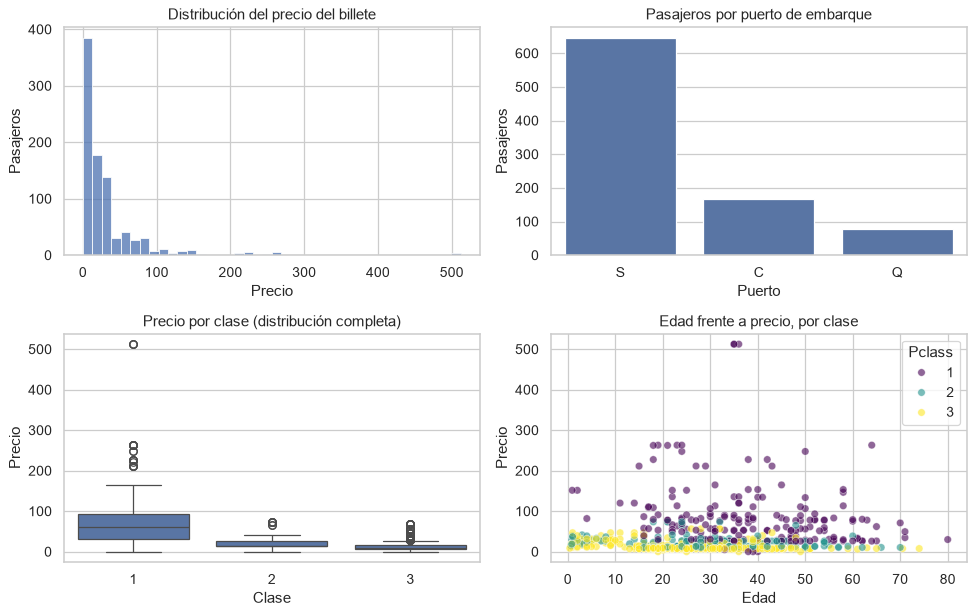

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# 1. DISTRIBUCIÓN: ¿cómo se reparten los precios de los billetes?
sns.histplot(data=df, x='Fare', bins=40, ax=axes[0, 0])
axes[0, 0].set_title('Distribución del precio del billete')
axes[0, 0].set_xlabel('Precio')
axes[0, 0].set_ylabel('Pasajeros')

# 2. CONTEO: ¿cuántos pasajeros por puerto?
sns.countplot(data=df, x='Embarked', ax=axes[0, 1])
axes[0, 1].set_title('Pasajeros por puerto de embarque')
axes[0, 1].set_xlabel('Puerto')
axes[0, 1].set_ylabel('Pasajeros')

# 3. DISPERSIÓN POR CATEGORÍA: el mismo precio, pero visto por clase
sns.boxplot(data=df, x='Pclass', y='Fare', ax=axes[1, 0])
axes[1, 0].set_title('Precio por clase (distribución completa)')
axes[1, 0].set_xlabel('Clase')
axes[1, 0].set_ylabel('Precio')

# 4. RELACIÓN: ¿tiene que ver la edad con lo que se pagó?
sns.scatterplot(data=df, x='Age', y='Fare', hue='Pclass',
                alpha=0.6, palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Edad frente a precio, por clase')
axes[1, 1].set_xlabel('Edad')
axes[1, 1].set_ylabel('Precio')

plt.tight_layout()
plt.show()

**Qué se ve.** El histograma confirma lo que `.describe()` insinuaba: casi todos los
billetes están por debajo de 100 y hay una cola larguísima de unos pocos carísimos, hasta
512. Esa forma —muchos valores pequeños, pocos enormes— es la razón de que la media de
`Fare` sea el doble que la mediana.

El tercer gráfico es el que hay que mirar dos veces. Un gráfico de barras diría "primera
clase, 84 de media" y se acabó. El de cajas enseña además que dentro de la primera clase los
precios están **dispersísimos**, mientras que en tercera están todos apelotonados en un
rango estrecho. Misma columna, misma pregunta, y solo uno de los dos gráficos cuenta esa
parte.

El de dispersión enseña una cosa más, y es un aviso: los puntos están ordenados por franjas
de color, es decir, **el precio lo explica la clase mucho mejor que la edad**. Cuando
buscabas una relación entre dos variables y lo que encuentras es que una tercera manda sobre
las dos, ya has aprendido algo del dataset.

---
## Ejercicio 2 — Mini-análisis del Titanic

**Contexto.** Un documental sobre el naufragio te contrata como analista. El guionista tiene
una tesis —"se salvaron los ricos"— y necesita saber si los datos la sostienen antes de
grabar. Te pide respuestas a seis preguntas concretas, y te avisa de algo: lo que salga hay
que poder enseñarlo en pantalla, así que donde haya un gráfico que lo cuente mejor que una
tabla, quiere el gráfico.

Tienes el DataFrame `df` ya cargado de las secciones anteriores.

**Tu tarea.**
1. **Supervivencia general.** ¿Cuántas personas sobrevivieron y cuántas murieron? Da los dos
   números y también el porcentaje sobre el total.
2. **Supervivencia por sexo.** ¿Qué porcentaje sobrevivió de los hombres y qué porcentaje de
   las mujeres?
3. **Limpieza.** A la columna `Age` le faltan valores. Rellénalos con la **mediana** de la
   edad de todos los pasajeros.
4. **Visualización por clase.** Un **gráfico de barras** con la tasa de supervivencia de cada
   clase (`Pclass`). ¿Qué clase tenía más probabilidades de sobrevivir?
5. **Visualización por edad.** Un **histograma** de `Age`, ya sin nulos. ¿Qué franja de edad
   era la más común a bordo?
6. **Una característica nueva.** Crea la columna `FamilySize`, que es `SibSp` (hermanos y
   cónyuges) más `Parch` (padres e hijos) más uno (el propio pasajero). Mira después si la
   supervivencia tiene algo que ver con ella.

**Criterio de que lo has hecho bien:** las tasas del punto 2 tienen que ser claramente
distintas entre sí, no dos cifras parecidas — si te salen parecidas, probablemente estás
contando personas en vez de calculando porcentajes. En el punto 4, el orden de las tres
clases no debería sorprenderte. El punto 6 es el único cuyo resultado **no** es monótono: si
te sale una línea que sube y ya está, revísalo.

Total de pasajeros: 891
Vivos: 342, Porcentaje: 38.38
Muertos: 549, Porcentaje: 61.62
Porcentaje: Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64:.2f
Valores nulos en la tabla: 'Age' rellenados con la mediana de la tabla original: 28.0


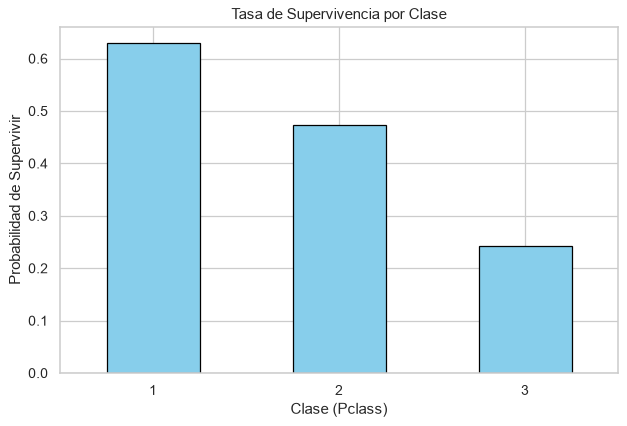

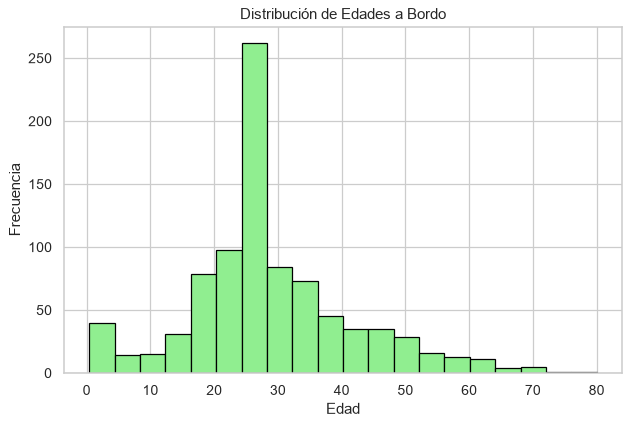

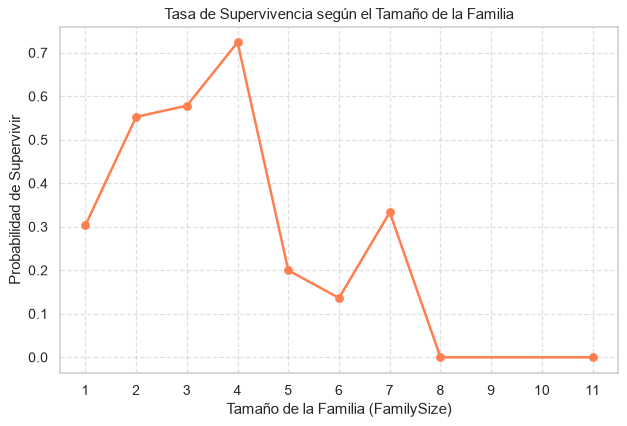

In [8]:
# TODO: completa esta celda
# Para las tasas no cuentes: la media de una columna de 0 y 1 ya es la proporción.
# Calcula la mediana de `Age` antes de rellenar, no después, o estarás usando un número contaminado.

# 1. Cargar desde una URL pública: read_csv acepta una ruta local o una dirección web
URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(URL)

#¿Cuántas personas sobrevivieron y cuántas murieron? Da los dos números y también el porcentaje sobre el total.
pasajeros = len(df['PassengerId'])
personas_vivas = sum(df['Survived'])#tabla binaria =1 sobrevio 0 no --> si sumas solo sumara los vivos.
muertos = pasajeros - personas_vivas

print(f"Total de pasajeros: {pasajeros}")
print(f"Vivos: {personas_vivas}, Porcentaje: {(personas_vivas*100)/pasajeros:.2f}")
print(f"Muertos: {muertos}, Porcentaje: {(muertos*100)/pasajeros:.2f}")

#¿Qué porcentaje sobrevivió de los hombres y qué porcentaje de las mujeres?
persVivaSexo = df.groupby("Sex")["Survived"].mean() * 100
print(f"Porcentaje: {persVivaSexo}:.2f")

#A la columna `Age` le faltan valores. Rellénalos con la **mediana** de la edad de todos los pasajeros.
mediana_edad = df["Age"].median()
df["Age"] = df["Age"].fillna(mediana_edad)
print(f"Valores nulos en la tabla: 'Age' rellenados con la mediana de la tabla original: {mediana_edad}")

#Visualización por clase.** Un **gráfico de barras** con la tasa de supervivencia de cada clase (`Pclass`). ¿Qué clase tenía más probabilidades de sobrevivir?
plt.figure(figsize=(8, 5))
tasa_clase = df.groupby("Pclass")["Survived"].mean()
tasa_clase.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Tasa de Supervivencia por Clase")
plt.xlabel("Clase (Pclass)")
plt.ylabel("Probabilidad de Supervivir")
plt.xticks(rotation=0)
plt.show()

#Visualización por edad.** Un **histograma** de `Age`, ya sin nulos. ¿Qué franja de edad era la más común a bordo?
plt.figure(figsize=(8, 5))
df["Age"].plot(kind="hist", bins=20, color="lightgreen", edgecolor="black")
plt.title("Distribución de Edades a Bordo")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

#Una característica nueva.** Crea la columna `FamilySize`, que es `SibSp` (hermanos y cónyuges) más `Parch` (padres e hijos) más uno (el propio pasajero). Mira después si la supervivencia tiene algo que ver con ella.
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

plt.figure(figsize=(8, 5))
tasa_familia = df.groupby("FamilySize")["Survived"].mean()
tasa_familia.plot(kind="line", marker="o", color="coral", linewidth=2)
plt.title("Tasa de Supervivencia según el Tamaño de la Familia")
plt.xlabel("Tamaño de la Familia (FamilySize)")
plt.ylabel("Probabilidad de Supervivir")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(range(1, df["FamilySize"].max() + 1))
plt.show()

### Mis reflexiones

*(Escribe aquí tu respuesta antes de seguir)*

- Has rellenado 177 edades con la mediana. Mira el histograma que has hecho: ¿qué le ha
  pasado por culpa de esa decisión? ¿En qué análisis te daría igual y en cuál no?
- El guionista quiere el titular "se salvaron los ricos". Con tus números, ¿se lo firmas?
  ¿Qué le dirías exactamente?
- La tasa de supervivencia por tamaño de familia sube y luego baja. Propón **dos**
  explicaciones distintas de por qué, y di qué dato te haría falta para saber cuál es.

---
## Preguntas de recap – Visualización con Seaborn

1. Quiero ver cómo se reparten los sueldos de una plantilla. Quiero comparar el sueldo medio
   entre tres departamentos. Quiero saber si el sueldo tiene que ver con la antigüedad.
   ¿Qué gráfico uso en cada caso?
2. ¿Qué diferencia hay entre `df.groupby()` y `df.value_counts()`?
3. Si queremos ordenar un DataFrame por la columna `"ventas"` de mayor a menor, ¿qué comando
   usamos?
4. ¿Por qué es importante visualizar los datos además de analizarlos con estadísticas?

## 6. Nota sobre el ecosistema: polars y `uv`

Dos herramientas que no vamos a usar en el curso pero que te vas a encontrar, y conviene que
sepas qué son cuando aparezcan.

**polars** es una alternativa a pandas, escrita en Rust. Hace lo mismo —DataFrames, filtros,
`group_by`— con una sintaxis distinta, bastante más rápida y con mejor comportamiento cuando
los datos no caben cómodamente en memoria. **No sustituye a pandas en este curso** por una
razón práctica: todo el ecosistema que viene después (scikit-learn, statsmodels, seaborn)
habla pandas de forma nativa, y casi todo el código que te vas a encontrar por ahí está
escrito en pandas. Aprende pandas primero; polars se lee sin esfuerzo después, y si algún día
tienes un fichero de veinte millones de filas que va lento, ya sabes a qué mirar.

**`uv`** es un gestor de paquetes y entornos de Python, también en Rust, que hace en segundos
lo que `pip` y `venv` hacían en minutos. Su gracia de verdad no es la velocidad: es que fija
las versiones exactas de todo en un fichero, de modo que tu proyecto se puede reinstalar
idéntico en otra máquina. Eso es lo que hace que un análisis sea **reproducible** — que el
código que hoy da 38,4 % siga dando 38,4 % dentro de un año y en el portátil de otra persona.
Si acabas compartiendo un proyecto, mira `uv` antes de mandar un `requirements.txt` a mano.

---
## Ejercicio 3 — El restaurante

**Contexto.** Un restaurante te pasa el registro de 244 mesas atendidas: lo que pagó cada
una, la propina que dejó, qué día fue, si era comida o cena, cuánta gente había en la mesa y
si eran fumadores. El dueño está pensando en pasar a **propina incluida** —un porcentaje fijo
en la cuenta— y antes quiere entender qué determina hoy lo que la gente deja. Su corazonada:
*"las mesas grandes son las que peor propina dejan"*.

Este es el ejercicio que integra toda la sesión, sobre un dataset que no habías visto.

**Tu tarea.**
1. Carga el fichero y haz el diagnóstico de siempre: tamaño, tipos, nulos.
2. Crea la columna `pct_propina`: la propina como **porcentaje** de la cuenta. Ojo, esta es
   la variable de la que va todo el ejercicio: la propina en euros y la propina en porcentaje
   responden a preguntas distintas.
3. ¿Cuál es el porcentaje medio de propina del restaurante?
4. Calcula el porcentaje medio de propina **por tamaño de mesa** y también cuántas mesas hay
   de cada tamaño. Responde a la corazonada del dueño.
5. Haz dos gráficos: uno que compare el porcentaje medio de propina entre los cuatro días de
   la semana, y otro que enseñe la relación entre el importe de la cuenta y el porcentaje de
   propina.
6. Cruza **dos** variables categóricas a la vez (por ejemplo día y sexo de quien paga, o día
   y momento del día) y mira si aparece algo que no se veía por separado.

**Datos:** `https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv`

**Criterio de que lo has hecho bien:** la corazonada del dueño se puede contestar con un sí o
un no, pero la respuesta útil lleva una advertencia pegada sobre **cuántas mesas** sostienen
cada cifra. Y en el punto 5, el segundo gráfico debería hacerte dudar de que "propina
incluida" sea tan buena idea como parece.

**Entrega:** el notebook con las celdas completadas y las tres reflexiones escritas.


------------------ Información general ------------------
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB
None

------------------ Resumen ------------------
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00
------------------ Nulos ------------------
total_bill    0
ti

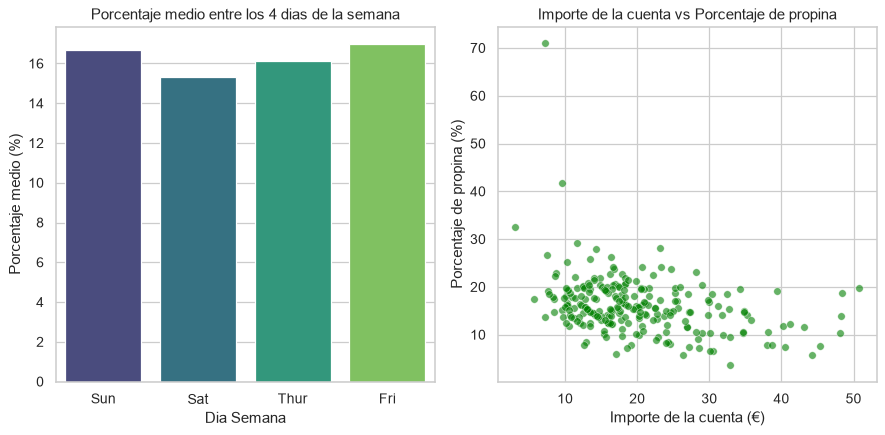

                mean  count
time   sex                 
Dinner Female  16.93     52
       Male    15.54    124
Lunch  Female  16.23     35
       Male    16.61     33


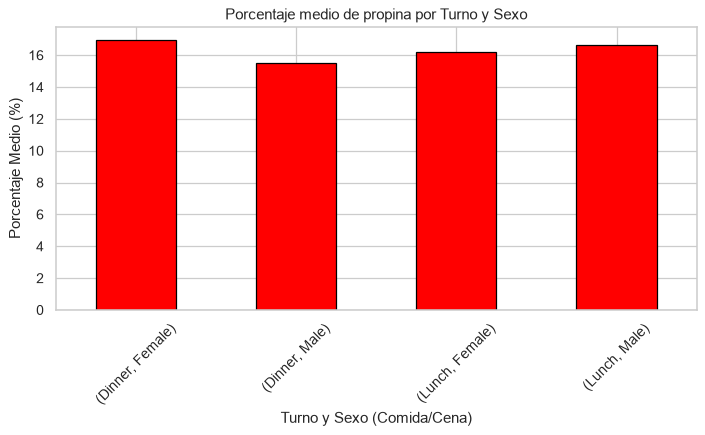

In [11]:
# TODO: completa esta celda
# El porcentaje de propina es una columna nueva, no una que venga en el fichero.
# Antes de dar por buena una media por grupo, mira cuántas filas tiene ese grupo: `.agg()` te da las dos cosas a la vez.

# 1. Carga el fichero y haz el diagnóstico de siempre: tamaño, tipos, nulos.
URL = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
df = pd.read_csv(URL)

## Tamaño, tipos y nulos
print("\n------------------ Información general ------------------")
print(df.info())

print("\n------------------ Resumen ------------------")
print(df.describe().round(2))

print("------------------ Nulos ------------------")
print(df.isnull().sum())

# 2. Crea la columna `pct_propina`: la propina como **porcentaje** de la cuenta. Ojo, esta es 
    # la variable de la que va todo el ejercicio: la propina en euros y la propina en porcentaje responden a preguntas distintas.
df["pct_propina"] = (df["tip"] / df["total_bill"]) * 100

# 3.¿Cuál es el porcentaje medio de propina del restaurante?
prc_medio = df["pct_propina"].mean()


# 4. Calcula el porcentaje medio de propina **por tamaño de mesa** y también cuántas 
    # mesas hay de cada tamaño. Responde a la corazonada del dueño.
mesas_df = df.groupby("size")["pct_propina"].agg(['mean', 'count']).round(2)


# 5. Haz dos gráficos: uno que compare el porcentaje medio de propina entre los cuatro días de la semana,
    # y otro que enseñe la relación entre el importe de la cuenta y el porcentaje de propina.
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

## Primer gráfico: Barplot (Barras)
sns.barplot(
      data=df, # Dataframe
      x='day', # Value at x
      y='pct_propina', # Value at y
      ax=axes[0], # Axes position
      errorbar=None, # Remove the line of error
      palette="viridis", # Change colors of each bar
      hue="day", # Asigna un valor de color distinto a cada dia de la semana
      legend=False) # Quitar legenda de colores generado por hue

axes[0].set_title('Porcentaje medio entre los 4 dias de la semana')
axes[0].set_xlabel('Dia Semana')
axes[0].set_ylabel('Porcentaje medio (%)')

## Segundo gráfico: Scatterplot

sns.scatterplot(
    data=df, 
    x='total_bill', 
    y='pct_propina', 
    ax=axes[1], 
    color="green", # Color of the points
    alpha=0.6 # Transparecia de los puntos
)
axes[1].set_title('Importe de la cuenta vs Porcentaje de propina')
axes[1].set_xlabel('Importe de la cuenta (€)')
axes[1].set_ylabel('Porcentaje de propina (%)')

plt.tight_layout()
plt.show()

# 6. Cruza **dos** variables categóricas a la vez (por ejemplo día y sexo de quien paga,
    #  o día y momento del día) y mira si aparece algo que no se veía por separado.
    
sex_time = df.groupby(["time", "sex"])["pct_propina"].agg(['mean', 'count']).round(2)

print(sex_time)

sex_time['mean'].plot(kind="bar", color="red", edgecolor="black", figsize=(8, 5))

plt.title("Porcentaje medio de propina por Turno y Sexo")
plt.xlabel("Turno y Sexo (Comida/Cena)")
plt.ylabel("Porcentaje Medio (%)")

# Etiquetas rotadas
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()



### Mis reflexiones

*(Escribe aquí tu respuesta)*

- El dueño quiere pasar a propina incluida del 16 %, que es justo la media. Con lo que has
  visto, ¿quién sale ganando y quién sale perdiendo con ese cambio?
- En el punto 4 hay cifras calculadas sobre 4 mesas y cifras calculadas sobre 156. Las dos
  se imprimen igual, con dos decimales. ¿Cómo presentarías esa tabla para que quien la lea
  no se fíe de las dos por igual?
- Has hecho el mismo tipo de análisis sobre el Titanic y sobre un restaurante. ¿Qué pasos has
  repetido exactamente igual en los dos? Esa lista es tu método de trabajo para el resto del
  curso: escríbela.